In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [17]:
node_pos_init = np.loadtxt('node_np.csv', delimiter=',')
node_pos_before = np.loadtxt('pos_before.csv', delimiter=',')
node_pos_after = np.loadtxt('pos_after_1000.csv', delimiter=',')

before_movement = node_pos_before - node_pos_init
after_movement = node_pos_after - node_pos_init

cos_error = []
nmse = []
rel_error = []

for i in range(len(before_movement)):
    if np.linalg.norm(before_movement[i]) == 0 or np.linalg.norm(after_movement[i]) == 0:
        nmse.append(0.)
        continue
    # cos_error.append(np.dot(before_movement[i], after_movement[i]) / (np.linalg.norm(before_movement[i]) * np.linalg.norm(after_movement[i])))
    nmse.append(np.sqrt(np.sum((before_movement[i] - after_movement[i])**2) / np.sum(before_movement[i]**2 + after_movement[i]**2)))
    # rel_error.append(np.linalg.norm(before_movement[i] - after_movement[i]) / np.linalg.norm(before_movement[i]))

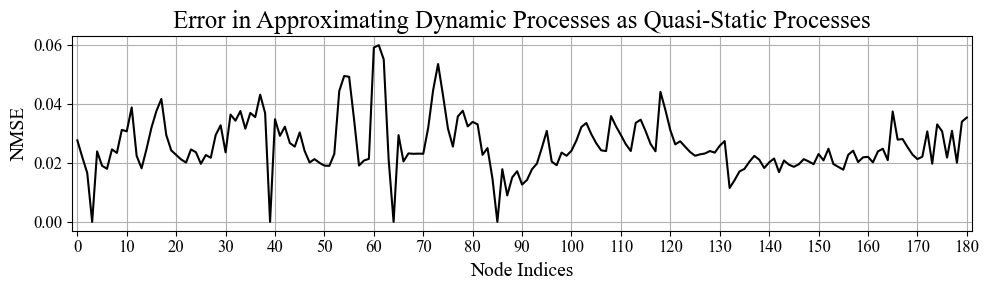

In [18]:
fig, axs = plt.subplots(1, 1, figsize=(10, 3))

axs.plot(nmse, c='k', lw=1.5, label='NMSE')
axs.set_xlim([-1, len(nmse)])
axs.set_title('Error in Approximating Dynamic Processes as Quasi-Static Processes', fontsize=18, fontname='Times New Roman')
axs.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
axs.set_ylabel('NMSE', fontsize=14, fontname='Times New Roman')
axs.xaxis.set_major_locator(MultipleLocator(10))
axs.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
axs.get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴中科学计数法中的指数大小
axs.grid('True')

plt.tight_layout()
plt.show()